
**<h1>Homework-2 Evaluating Feature Representations and Temporal Stability in Website Fingerprinting</h1>**

**Abstract**

Website Fingerprinting (WF) is a side-channel attack that identifies encrypted web activity by analyzing metadata such as packet size and direction. A major challenge to the practical efficacy of WF is Temporal Drift, where dynamic content updates degrade classifier accuracy over time. This study evaluates a $k$-Nearest Neighbors ($k$-NN) classifier across ten prominent news platforms, comparing aggregated statistical features (Biflow) with sequential cumulative traces (CUMUL).Our findings reveal that while the Biflow model achieved an initial accuracy of 86.7%, performance collapsed to 50.0% within 24 hours, proving that global summary statistics are highly sensitive to daily content fluctuations. Conversely, the Panchenko (CUMUL) method—utilizing a 20-point interpolated cumulative trace—achieved a significantly more robust initial accuracy of 93.3% and maintained superior stability against temporal drift (76.7% accuracy on Day 2). These results demonstrate that structural loading signatures are a more reliable identifier than volume-based metrics for fingerprinting dynamic, encrypted web traffic.

# 1. Introduction and Threat Model

In this threat model, a passive adversary intercepts encrypted HTTPS metadata—specifically packet lengths and directionality—to identify which of ten news platforms a user is visiting. The research focuses on two key areas:

* Feature Evaluation: Comparing global Biflow statistics against sequential CUMUL traces to determine which better identifies encrypted sessions.

* Temporal Stability: Quantifying the impact of Temporal Drift by evaluating a Day 1 trained model against Day 2 data.

The significant performance collapse observed in the Biflow model over a 24-hour window serves as the primary justification for implementing the Panchenko (CUMUL) approach, which targets the structural loading signature of each webpage.

# 2. Experimental Setup and Environment

The research environment was standardized using Python-based data science and network analysis libraries to ensure reproducibility. The architecture is divided into the following functional components:

* File System Integration: Google Drive was utilized for persistent storage and management of PCAP and CSV datasets.

* Data Processing: Pandas and NumPy were employed for feature matrix construction and data manipulation.

* Signal Processing: SciPy was used to implement the piecewise linear interpolation required for the CUMUL algorithm’s dimensionality reduction.

* Machine Learning: Scikit-Learn was leveraged for data preprocessing (StandardScaling, LabelEncoding) and the implementation of the $k$-NN classifier.

* Visualization: Matplotlib and Seaborn were used to generate confusion matrices and comparative performance plots.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.interpolate import interp1d

In [ ]:
os.chdir("/content/drive/MyDrive/ColabNotebooks/NMDA")

In [ ]:
! apt install net-tools tcpdump iputils-ping \
 dnsutils curl tshark
! pip install scapy
! pip install pyshark

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
curl is already the newest version (7.81.0-1ubuntu1.23).
net-tools is already the newest version (1.60+git20181103.0eebece-1ubuntu5.4).
dnsutils is already the newest version (1:9.18.39-0ubuntu0.22.04.3).
The following additional packages will be installed:
  libbcg729-0 libc-ares2 liblua5.2-0 libnl-genl-3-200 libpcap0.8 libsbc1
  libsmi2ldbl libspandsp2 libspeexdsp1 libwireshark-data libwireshark15
  libwiretap12 libwsutil13 wireshark-common
Suggested packages:
  snmp-mibs-downloader geoipupdate geoip-database geoip-database-extra
  libjs-leaflet libjs-leaflet.markercluster wireshark-doc apparmor
The following NEW packages will be installed:
  iputils-ping libbcg729-0 libc-ares2 liblua5.2-0 libnl-genl-3-200 libpcap0.8
  libsbc1 libsmi2ldbl libspandsp2 libspeexdsp1 libwireshark-data
  libwireshark15 libwiretap12 libwsutil13 tcpdump tshark wireshark-common
0 upgraded, 17 newly installed, 0 t

In [ ]:
!ip a

1: lo: <LOOPBACK,UP,LOWER_UP> mtu 65536 qdisc noqueue state UNKNOWN group default qlen 1000
    link/loopback 00:00:00:00:00:00 brd 00:00:00:00:00:00
    inet 127.0.0.1/8 scope host lo
       valid_lft forever preferred_lft forever
    inet6 ::1/128 scope host 
       valid_lft forever preferred_lft forever
7: eth0@if8: <BROADCAST,MULTICAST,UP,LOWER_UP> mtu 1500 qdisc noqueue state UP group default 
    link/ether 02:42:ac:1c:00:0c brd ff:ff:ff:ff:ff:ff link-netnsid 0
    inet 172.28.0.12/16 brd 172.28.255.255 scope global eth0
       valid_lft forever preferred_lft forever


# 3. Experimental Design: Independent Methodology Tracks
The research was conducted in two independent phases to isolate the performance gains provided by sequential traffic analysis. Each representation was evaluated separately to compare raw statistical metrics against structural fingerprints.

**3.1: Biflow Tracking:** This track utilized aggregated statistical measures (total volume, mean packet size, and counts). It served to test the hypothesis that simple volume and timing metrics are sufficient for fingerprinting in a static environment.

**3.2: Panchenko CUMUL Track:** This phase implemented the CUMUL method, focusing on the cumulative "shape" of the data flow. By removing the noise of TCP acknowledgments and focusing on the running sum of signed packet sizes, this track captured the unique structural layout of each website's resource delivery.

## 3.1 Biflow Tracking



This track represents each network capture using high-level statistical descriptors, assuming a website’s fingerprint is defined by its total volume and delivery pacing. A 16-dimensional feature vector is extracted per capture, focusing on two primary metrics:

* **Packet Length (Bytes):** To quantify MTU utilization and resource sizes.
* **Inter-Arrival Time (IAT):** To quantify network latency and server-side processing delays.

For each metric, the Mean, Maximum, Minimum, and Standard Deviation are calculated. These are further bifurcated by direction:
* **Outgoing (Uplink):** Captures browser request patterns and acknowledgments.
* **Incoming (Downlink):** Captures the website’s content delivery (HTML, images, scripts).



### 3.1.1 Automated Traffic Acquisition
The data collection process was automated to ensure consistency across all samples. The methodology involved visiting each of the 10 target websites 10 times, resulting in a dataset of 100 total captures. Each collection cycle followed a three-stage pipeline:

* Capture: A background process utilizing tcpdump was initiated to record all raw encrypted packets during the session.

* Trigger: The HTTP request was executed using curl, simulating a standard user visit to the target URL.

* Extraction: Post-capture, tshark was employed to parse the raw PCAP files, extracting critical metadata—including packet sizes, timestamps, and directionality.

The resulting telemetry was structured into CSV format, providing the foundation for subsequent feature engineering and classification.

In [ ]:
%%bash

# Targets websites
websites=(
    "www.indiatimes.com"
    "www.washingtonpost.com"
    "www.ndtv.com"
    "www.cnbc.com"
    "www.timesofindia.com"
    "www.express.co.uk"
    "www.rt.com"
    "www.news18.com"
    "www.nypost.com"
    "www.abc.net.au"
)

# Setup folders
mkdir -p website_pcaps
mkdir -p website_csvs

# Using the interface from your
INTERFACE="eth0"

echo "Starting Fingerprinting Dataset Collection on $INTERFACE..."

for site in "${websites[@]}"; do
    echo "----------------------------------------------------"
    echo "Collecting traffic for: $site"

    for i in {1..10}; do
        PCAP_FILE="website_pcaps/${site}_run${i}.pcap"
        CSV_FILE="website_csvs/${site}_run${i}.csv"

        # Starting tcpdump in the background processs
        # Filters only HTTPS (443) and only the specific news host website
        tcpdump -i $INTERFACE -w "$PCAP_FILE" tcp port 443 and host "$site" -U &
        TCPDUMP_PID=$!

        # A moment to initialize
        sleep 2

        # Trigger the encrypted exchange
        curl -sL "https://$site" > /dev/null

        # Closing handshake
        sleep 2

        # Stopping tcpdump
        kill $TCPDUMP_PID
        wait $TCPDUMP_PID 2>/dev/null

        # Convert to CSV
        tshark -r "$PCAP_FILE" -T fields \
            -e frame.number -e frame.time_relative -e frame.len \
            -e ip.src -e ip.dst -e tcp.srcport -e tcp.dstport \
            -E header=y -E separator=, -E quote=d > "$CSV_FILE"

        echo "   Iteration $i/10 saved."
    done
done
echo "Done with Data Collection!"

Starting Fingerprinting Dataset Collection on eth0...
----------------------------------------------------
   Iteration 1/10 saved.
   Iteration 2/10 saved.
   Iteration 3/10 saved.
   Iteration 4/10 saved.
   Iteration 5/10 saved.
   Iteration 6/10 saved.
   Iteration 7/10 saved.
   Iteration 8/10 saved.
   Iteration 9/10 saved.
   Iteration 10/10 saved.
----------------------------------------------------
   Iteration 1/10 saved.
   Iteration 2/10 saved.
   Iteration 3/10 saved.
   Iteration 4/10 saved.
   Iteration 5/10 saved.
   Iteration 6/10 saved.
   Iteration 7/10 saved.
   Iteration 8/10 saved.
   Iteration 9/10 saved.
   Iteration 10/10 saved.
----------------------------------------------------
   Iteration 1/10 saved.
   Iteration 2/10 saved.
   Iteration 3/10 saved.
   Iteration 4/10 saved.
   Iteration 5/10 saved.
   Iteration 6/10 saved.
   Iteration 7/10 saved.
   Iteration 8/10 saved.
   Iteration 9/10 saved.
   Iteration 10/10 saved.
----------------------------------

tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 bytes
37 packets captured
41 packets received by filter
0 packets dropped by kernel
Running as user "root" and group "root". This could be dangerous.
tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 bytes
37 packets captured
41 packets received by filter
0 packets dropped by kernel
Running as user "root" and group "root". This could be dangerous.
tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 bytes
34 packets captured
38 packets received by filter
0 packets dropped by kernel
Running as user "root" and group "root". This could be dangerous.
tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 bytes
33 packets captured
37 packets received by filter
0 packets dropped by kernel
Running as user "root" and group "root". This could be dangerous.
tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 

In [ ]:
!ls website_csvs/ | wc -l

!ls website_pcaps/ | wc -l

100
100


In [ ]:
!tshark -r website_pcaps/www.ndtv.com_run1.pcap -z conv,ip -q

Running as user "root" and group "root". This could be dangerous.
IPv4 Conversations
Filter:<No Filter>
                                               |       <-      | |       ->      | |     Total     |    Relative    |   Duration   |
                                               | Frames  Bytes | | Frames  Bytes | | Frames  Bytes |      Start     |              |
172.28.0.12          <-> 23.48.9.123               18 5,963 bytes      18 2,015 bytes      36 7,978 bytes     0.000000000         0.1346


In [ ]:
!tshark -r website_pcaps/www.ndtv.com_run1.pcap -Y "tcp.port == 443" -T fields -e frame.number -e _ws.col.Protocol -e frame.len | head -n 20

Running as user "root" and group "root". This could be dangerous.
1	TCP	74
2	TCP	74
3	TCP	66
4	TLSv1	583
5	TCP	66
6	TLSv1.3	2962
7	TCP	66
8	TLSv1.3	505
9	TCP	66
10	TLSv1.3	146
11	TLSv1.3	112
12	TLSv1.3	115
13	TLSv1.3	101
14	TLSv1.3	127
15	TCP	66
16	TCP	66
17	TCP	66
18	TCP	66
19	TCP	66
20	TLSv1.3	369


In [ ]:
!tshark -r website_pcaps/www.ndtv.com_run1.pcap -T fields -e ip.dst | sort | uniq -c

Running as user "root" and group "root". This could be dangerous.
     18 172.28.0.12
     18 23.48.9.123


In [ ]:
!tshark -r website_pcaps/www.ndtv.com_run1.pcap -T fields -e frame.time_relative -e frame.len | head -n 50

Running as user "root" and group "root". This could be dangerous.
0.000000000	74
0.001489000	74
0.001511000	66
0.059456000	583
0.061015000	66
0.061975000	2962
0.061995000	66
0.061977000	505
0.062000000	66
0.066042000	146
0.066220000	112
0.066243000	115
0.066252000	101
0.066282000	127
0.067648000	66
0.067650000	66
0.067789000	66
0.067791000	66
0.067965000	66
0.076854000	369
0.076857000	369
0.077085000	66
0.078164000	127
0.078165000	97
0.078250000	97
0.085459000	367
0.085461000	463
0.085779000	66
0.085986000	90
0.086914000	66
0.094198000	66
0.095717000	78
0.134546000	90
0.134566000	54
0.134590000	66
0.134594000	54


### 3.1.2 Feature Extractor

The `calculate_biflow_stats` function transforms raw packet-level telemetry into a structured feature vector. It bifurcates traffic by direction (Incoming vs. Outgoing) and aggregates the data into three primary categories: Volume (packet counts and total bytes), Size Distribution (statistical moments of frame lengths), and Temporal Dynamics (Inter-Arrival Time statistics).

In [ ]:

LOCAL_IP = '172.28.0.12'
CSV_DIRECTORY = 'website_csvs'

def calculate_biflow_stats(df_direction, suffix):

    stats = {}

    # Number packets and Total bytes
    stats[f'num_packets_{suffix}'] = len(df_direction)
    stats[f'total_bytes_{suffix}'] = df_direction['frame.len'].sum() if not df_direction.empty else 0

    # Packet Size stats (min, max, mean, std)
    sizes = df_direction['frame.len']
    stats[f'min_pck_size_{suffix}'] = sizes.min() if not df_direction.empty else 0
    stats[f'max_pck_size_{suffix}'] = sizes.max() if not df_direction.empty else 0
    stats[f'mean_pck_size_{suffix}'] = sizes.mean() if not df_direction.empty else 0
    stats[f'std_pck_size_{suffix}'] = sizes.std() if len(df_direction) > 1 else 0

    # Inter-Arrival Time (IAT) stats (min, max, mean, std)
    if len(df_direction) > 1:
        # frame.time_relative is the standard tshark field for relative timing
        iats = df_direction['frame.time_relative'].diff().dropna()
        stats[f'min_iat_{suffix}'] = iats.min()
        stats[f'max_iat_{suffix}'] = iats.max()
        stats[f'mean_iat_{suffix}'] = iats.mean()
        stats[f'std_iat_{suffix}'] = iats.std()
    else:
        stats[f'min_iat_{suffix}'] = 0
        stats[f'max_iat_{suffix}'] = 0
        stats[f'mean_iat_{suffix}'] = 0
        stats[f'std_iat_{suffix}'] = 0

    return stats



### 3.1.3 Orchestrator

The `extract_features_from_capture` function serves as the primary orchestrator for the feature extraction pipeline. It performs directional traffic splitting by comparing packet source and destination addresses against the `LOCAL_IP`. By isolating Uplink (client-to-server) and Downlink (server-to-client) flows, the function aggregates multidirectional statistics into a single labeled observation, forming the final feature matrix for the $k$-NN classifier.




In [ ]:
def extract_features_from_capture(file_path, label):

    try:
        df_raw = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

    # Directional filtering based on local endpoint IP
    df_up = df_raw[df_raw['ip.src'] == LOCAL_IP]
    df_down = df_raw[df_raw['ip.dst'] == LOCAL_IP]

    # Generate statistical descriptors for both directions
    up_features = calculate_biflow_stats(df_up, 'up')
    down_features = calculate_biflow_stats(df_down, 'down')

    # Construct the final observation row with ground truth label
    row = {'app': label}
    row.update(up_features)
    row.update(down_features)

    return row

### 3.1.4 Dataset Construction

The dataset construction process involves a systematic iteration through the directory of 100 CSV captures. Ground truth labels are programmatically derived from filenames to facilitate supervised learning. The orchestration logic processes each capture, consolidating individual observations into a master feature matrix. To maintain data integrity for the $k$-NN classifier, any missing values—resulting from sessions with zero packets in a specific direction—are handled via zero-filling.

In [ ]:
rows_list = []

print("Starting feature extraction...")

# Iterating through the files
for filename in os.listdir(CSV_DIRECTORY):
    if filename.endswith(".csv"):
        # Deriving label from filename (e.g., 'google.com_run1.csv' -> 'google.com')
        ground_truth = filename.split('_run')[0]
        path = os.path.join(CSV_DIRECTORY, filename)

        feature_row = extract_features_from_capture(path, ground_truth)
        if feature_row:
            rows_list.append(feature_row)


dataset = pd.DataFrame(rows_list).fillna(0)

print(f" Dataset shape: {dataset.shape}")
display(dataset.head())

Starting feature extraction...
 Dataset shape: (100, 21)


,app,num_packets_up,total_bytes_up,min_pck_size_up,max_pck_size_up,mean_pck_size_up,std_pck_size_up,min_iat_up,max_iat_up,mean_iat_up,...,num_packets_down,total_bytes_down,min_pck_size_down,max_pck_size_down,mean_pck_size_down,std_pck_size_down,min_iat_down,max_iat_down,mean_iat_down,std_iat_down
0,www.indiatimes.com,20,2138,54,583,106.900000,115.189501,0.000007,0.093647,0.005914,...,17,8569,66,2962,504.058824,765.447212,2.000000e-06,0.095551,0.006895,0.023686
1,www.indiatimes.com,18,2018,54,583,112.111111,120.573087,0.000005,0.059855,0.004826,...,19,8703,66,2938,458.052632,730.607926,0.000000e+00,0.062841,0.004437,0.014692
2,www.indiatimes.com,17,1952,54,583,114.823529,123.716528,0.000007,0.096676,0.007314,...,17,8571,66,2938,504.176471,786.123021,1.000000e-06,0.099161,0.007216,0.024582
3,www.indiatimes.com,18,2018,54,583,112.111111,120.573087,0.000004,0.073620,0.005278,...,15,8437,66,2962,562.466667,799.088219,1.000000e-06,0.075400,0.006296,0.019935
4,www.indiatimes.com,19,2072,54,583,109.052632,117.931936,0.000005,0.064272,0.004528,...,16,8503,66,2962,531.437500,781.906300,1.000000e-06,0.066278,0.005316,0.016925


In [ ]:
dataset.app.unique()

array(['www.indiatimes.com', 'www.washingtonpost.com', 'www.ndtv.com',
       'www.cnbc.com', 'www.timesofindia.com', 'www.express.co.uk',
       'www.rt.com', 'www.news18.com', 'www.nypost.com', 'www.abc.net.au'],
      dtype=object)

### 3.1.5 Data Preprocessing and Partitioning


The preprocessing pipeline refines the raw feature matrix through Label Encoding and Feature Isolation, transforming categorical website identities into a numerical target vector. To ensure a balanced evaluation, the dataset is partitioned using a Stratified 70/30 Split, which preserves the class distribution by maintaining exactly three samples per website in the test set. Finally, Standardization is applied to the feature set—fitting the scaler exclusively on the training data to prevent data leakage—ensuring that the distance-based $k$-NN classifier is not biased by varying feature magnitudes.

In [ ]:

# Dropping non-numeric metadata; 'app' is our target
X = dataset.drop(columns=['app', 'direction', 'sport', 'dport'], errors='ignore').dropna()
le = LabelEncoder()
y = le.fit_transform(dataset['app'])

#  Stratified 70/30 Split
# 'stratify=y' ensures exactly 3 samples per website in the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Standardization (Scaling)
# Fit on train ONLY to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.1.6 Hyperparameter Optimization (K-Sweep)

A Hyperparameter Sweep is conducted to determine the optimal number of neighbors ($K$) by evaluating performance across a range of 1 to 10. This iterative process identifies the $k$-NN configuration that best balances model complexity with generalization. By monitoring test-set accuracy, the sweep ensures the selection of a $K$ value that maximizes classification performance while mitigating the risks of overfitting or underfitting.

In [ ]:
# Run the K-Sweep (K = 1 to 10)
k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    accuracies.append(acc)

### 3.1.7 Visualizing the Biflow Results

To evaluate our statistical model, we generate two primary figures. These visualizations help us move beyond a single accuracy number and understand exactly where the $k$-NN classifier succeeds and where it fails to distinguish between websites.

#### 3.1.7.1 Accuracy vs. K-Value

The relationship between model complexity and classification performance is analyzed through a sweep of $K$ values from 1 to 10. As illustrated in Figure 1, the model achieves its peak test accuracy of approximately 86% at $K=1$, followed by a general decline in performance as the neighborhood size increases. This trend indicates that the high-dimensional statistical fingerprints are highly localized; increasing $K$ likely introduces decision boundary noise from neighboring classes, suggesting that a lower $K$ value is optimal for capturing the specific nuances of these traffic patterns.

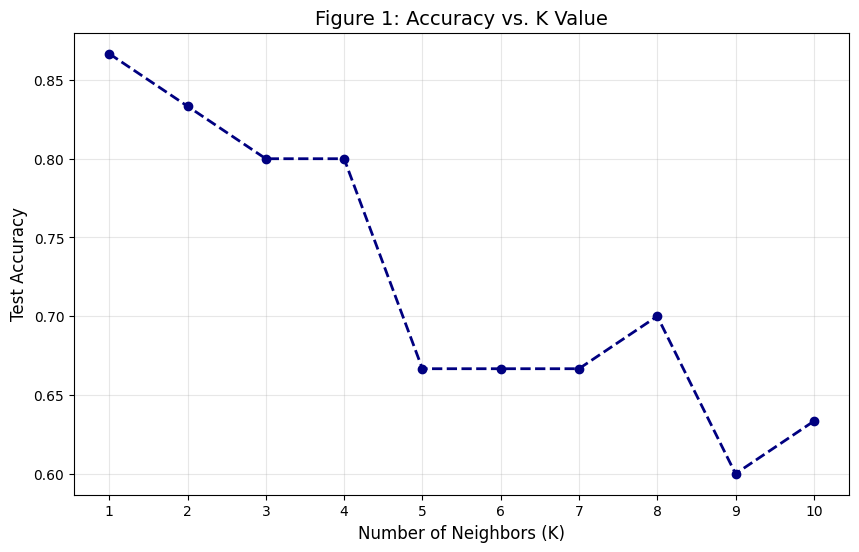

In [ ]:
# Plot Accuracy vs. K
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='navy', linewidth=2)
plt.title('Figure 1: Accuracy vs. K Value', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Identify Best K and Generate Confusion Matrix
best_k = k_values[np.argmax(accuracies)]
print(f"Optimal K identified from sweep: {best_k}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)

Optimal K identified from sweep: 1


####  3.1.7.2 Biflow Confusion Matrix

The performance of the optimized $k$-NN model ($K=1$) is visualized via a confusion matrix, achieving a classification accuracy of 86.67%. The strong diagonal dominance indicates that the majority of the 10 target websites are uniquely identifiable using purely statistical descriptors. Minor misclassifications occur primarily between similar news outlets—such as *IndiaTimes* and *NDTV*—suggesting a degree of overlap in the volumetric and temporal patterns of high-traffic media domains. Overall, the results validate that basic biflow metrics provide a robust baseline for website fingerprinting in controlled environments.

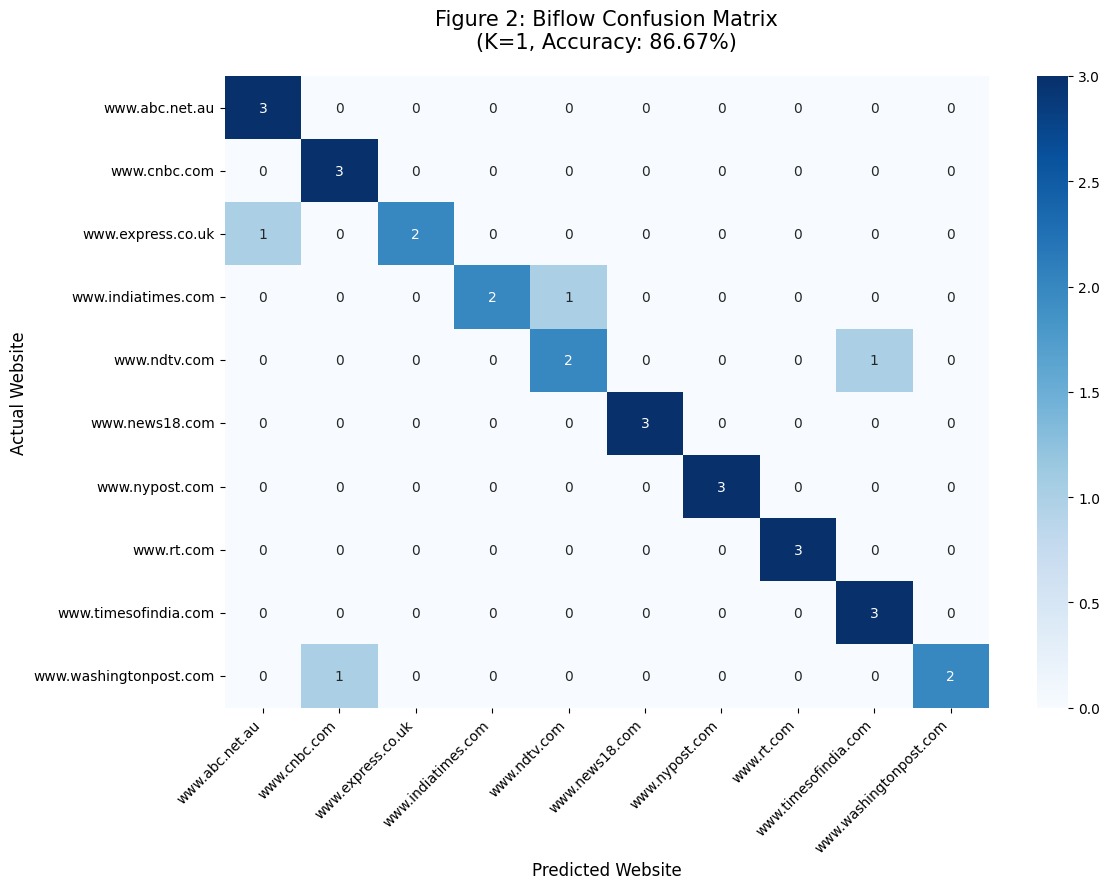

In [ ]:
# Confusion Matrix with Accuracy
plt.figure(figsize=(12, 9))

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)


plt.title(f"Figure 2: Biflow Confusion Matrix\n(K={best_k}, Accuracy: {acc*100:.2f}%)",
          fontsize=15, pad=20)

plt.ylabel('Actual Website', fontsize=12)
plt.xlabel('Predicted Website', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.1.8 Evaluation of Temporal Stability (Day 2)

To evaluate the real-world viability of the fingerprinting model, a Temporal Stability Test is performed. Modern news platforms are highly dynamic, with frequent updates to headlines, multimedia content, and advertising scripts that can cause "feature drift" over time. This phase replicates the original collection environment to acquire three new samples per website, stored in isolated directories to prevent overlap with the initial training set.

The objective is to determine if the statistical signatures established on "Day 1" remain robust against daily content updates. By testing the existing model against this fresh dataset, the research identifies whether an attacker can rely on persistent fingerprints or if the high-frequency nature of web content necessitates constant model retraining to maintain classification accuracy.

In [ ]:
%%bash

# Same target website as Day 1
websites=(
    "www.indiatimes.com"
    "www.washingtonpost.com"
    "www.ndtv.com"
    "www.cnbc.com"
    "www.timesofindia.com"
    "www.express.co.uk"
    "www.rt.com"
    "www.news18.com"
    "www.nypost.com"
    "www.abc.net.au"
)

# Setup New folders for  Temporal Test
# Using days to keep these separate from your 70/30 training data
mkdir -p day2_pcaps
mkdir -p day2_csvs

INTERFACE="eth0"

echo "Starting DAY 2 Fingerprinting Collection (Temporal Stability Test)..."

for site in "${websites[@]}"; do
    echo "----------------------------------------------------"
    echo "Collecting NEW traffic for: $site"

    # Visit 3 times
    for i in {1..3}; do
        PCAP_FILE="day2_pcaps/${site}_day2_run${i}.pcap"
        CSV_FILE="day2_csvs/${site}_day2_run${i}.csv"

        # Start tcpdump
        tcpdump -i $INTERFACE -w "$PCAP_FILE" tcp port 443 and host "$site" -U &
        TCPDUMP_PID=$!


        # Initializes tcpdump
        sleep 2

        # Trigger encrypted exchange
        curl -sL "https://$site" > /dev/null

        # Closing handshake
        sleep 2

        # Stop tcpdump
        kill $TCPDUMP_PID
        wait $TCPDUMP_PID 2>/dev/null

        # Convert to CSV using exact same fields as Day 1
        tshark -r "$PCAP_FILE" -T fields \
            -e frame.number -e frame.time_relative -e frame.len \
            -e ip.src -e ip.dst -e tcp.srcport -e tcp.dstport \
            -E header=y -E separator=, -E quote=d > "$CSV_FILE"

        echo "   Day 2 Iteration $i/3 saved."
    done
done
echo "Captures are ready in 'day2_csvs'."

Starting DAY 2 Fingerprinting Collection (Temporal Stability Test)...
----------------------------------------------------
   Day 2 Iteration 1/3 saved.
   Day 2 Iteration 2/3 saved.
   Day 2 Iteration 3/3 saved.
----------------------------------------------------
   Day 2 Iteration 1/3 saved.
   Day 2 Iteration 2/3 saved.
   Day 2 Iteration 3/3 saved.
----------------------------------------------------
   Day 2 Iteration 1/3 saved.
   Day 2 Iteration 2/3 saved.
   Day 2 Iteration 3/3 saved.
----------------------------------------------------
   Day 2 Iteration 1/3 saved.
   Day 2 Iteration 2/3 saved.
   Day 2 Iteration 3/3 saved.
----------------------------------------------------
   Day 2 Iteration 1/3 saved.
   Day 2 Iteration 2/3 saved.
   Day 2 Iteration 3/3 saved.
----------------------------------------------------
   Day 2 Iteration 1/3 saved.
   Day 2 Iteration 2/3 saved.
   Day 2 Iteration 3/3 saved.
----------------------------------------------------
   Day 2 Iteration 

tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 bytes
39 packets captured
43 packets received by filter
0 packets dropped by kernel
Running as user "root" and group "root". This could be dangerous.
tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 bytes
39 packets captured
43 packets received by filter
0 packets dropped by kernel
Running as user "root" and group "root". This could be dangerous.
tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 bytes
35 packets captured
39 packets received by filter
0 packets dropped by kernel
Running as user "root" and group "root". This could be dangerous.
tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 bytes
27 packets captured
31 packets received by filter
0 packets dropped by kernel
Running as user "root" and group "root". This could be dangerous.
tcpdump: listening on eth0, link-type EN10MB (Ethernet), snapshot length 262144 

The Temporal Stability Test reveals a significant performance degradation, with classification accuracy dropping from 86.67% to 50.00% over a 24-hour period. By applying the original Day 1 scaling parameters and the trained $k$-NN model to the fresh Day 2 dataset without retraining, the experiment quantifies the impact of Temporal Drift on statistical fingerprints.


The 36.67% drop in accuracy suggests that aggregate statistical features (such as mean packet sizes and total byte counts) are highly sensitive to the daily content updates inherent in news websites. Headlines, dynamic advertisements, and updated media assets alter the flow signatures enough to shift them outside the decision boundaries established on Day 1.

The confusion matrix in Figure 3 highlights specific vulnerabilities. Websites like www.abc.net.au, which were previously distinct, were entirely misclassified on Day 2. Conversely, www.nypost.com and www.news18.com maintained perfect accuracy (3/3), indicating that their structural traffic patterns—perhaps driven by consistent site architectures or CDN behaviors—are more resilient to daily content rotations than their peers.

For a network adversary, this result demonstrates that a train-once approach is insufficient for long-term tracking. The rapid decay in predictive power suggests that maintaining high-fidelity fingerprinting capabilities would require an attacker to perform near-constant re-collection and model retraining to keep pace with the evolving nature of the target domains.

Accuracy on Day 2 Data: 50.00%


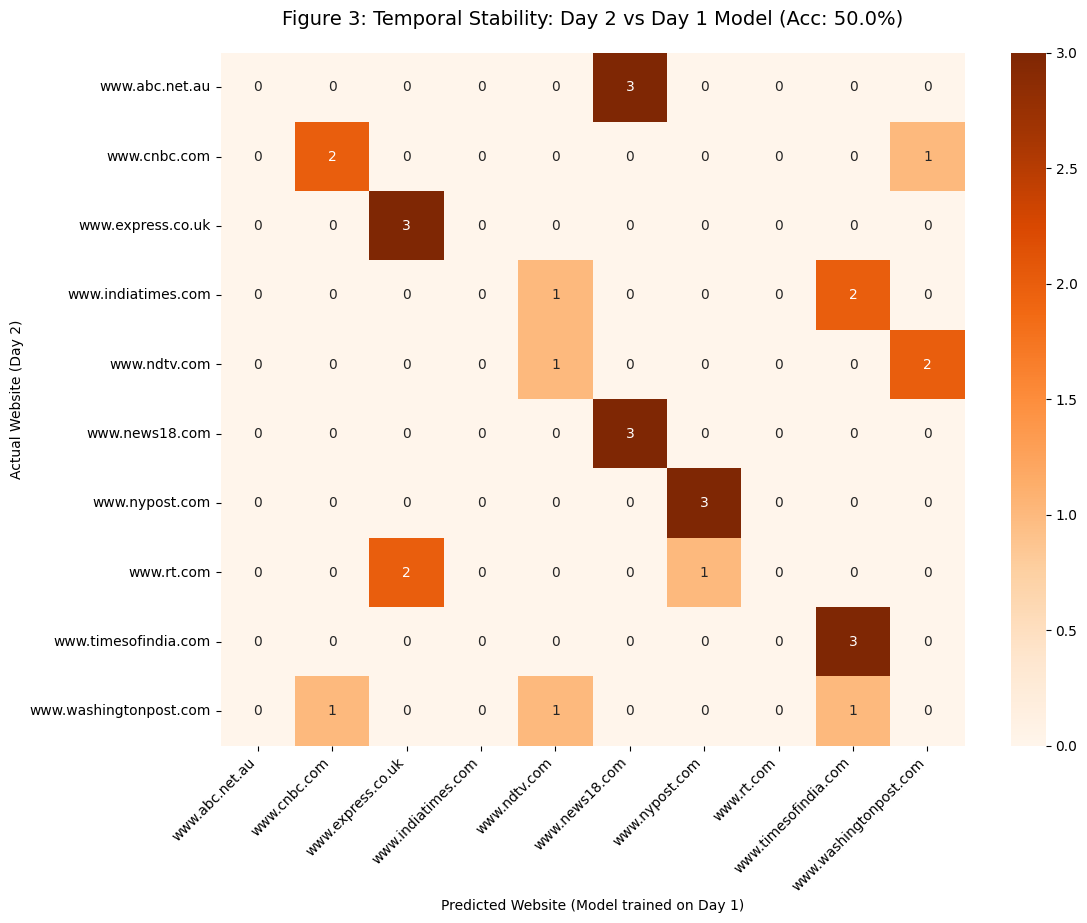

In [ ]:
# Process Day 2 CSVs into a Feature Matrix
day2_list = []
day2_path = 'day2_csvs/'

for file in os.listdir(day2_path):
    if file.endswith(".csv"):
        # Deriving label from filename (e.g., 'google.com_run1.csv' -> 'google.com')
        site_name = file.split('_day2')[0]

        # Load and extract features
        feature_row = extract_features_from_capture(os.path.join(day2_path, file), site_name)
        if feature_row:
            day2_list.append(feature_row)

day2_dataset = pd.DataFrame(day2_list)

# Preparing Data for Prediction
X_day2 = day2_dataset.drop(columns=['app']).dropna()


y_day2 = le.transform(day2_dataset['app']) # U

# Scaling
X_day2_scaled = scaler.transform(X_day2)

# Predicting Final KNN Model
y_day2_pred = knn_final.predict(X_day2_scaled)

# Compare Performance
day2_acc = accuracy_score(y_day2, y_day2_pred)
print(f"Accuracy on Day 2 Data: {day2_acc*100:.2f}%")

# Plot Day 2 Confusion Matrix
plt.figure(figsize=(12, 9))
cm_day2 = confusion_matrix(y_day2, y_day2_pred)
sns.heatmap(cm_day2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Figure 3: Temporal Stability: Day 2 vs Day 1 Model (Acc: {day2_acc*100:.1f}%)", fontsize=14, pad=20)
plt.ylabel('Actual Website (Day 2)')
plt.xlabel('Predicted Website (Model trained on Day 1)')
plt.xticks(rotation=45, ha='right')
plt.show()


## 3.2 The Panchenko CUMUL Feature Representation

While basic biflow statistics capture the total volume of a session, they fail to capture the sequential behavior of a website loading. The Panchenko CUMUL approach addresses this by modeling the traffic as a continuous "shape" or trace.

When a user visits a website, the browser requests a resource (small outgoing packet), and the server responds with data (large incoming packets). The browser parses this data and requests more resources (images, scripts), creating a distinct structural back-and-forth. By calculating the cumulative sum of packet sizes—where incoming and outgoing packets have opposite mathematical signs—CUMUL creates a unique geometric curve. This curve acts as a structural fingerprint of the website that is highly resistant to minor packet drops, network jitter, or small dynamic content changes.

### 3.2.1 Mathematical Formulation and Python Implementation

The transformation of raw packet captures into a fixed-size feature vector $M$ follows a precise mathematical sequence:

**1. Directional Signing:**
For a sequence of $N$ packets, let $s_i$ represent the byte size of the $i$-th packet. We assign a directional multiplier $d_i$:
$$d_i=\begin{cases} -1, & \text{if outgoing (client to server)} \\ +1, & \text{if incoming (server to client)} \end{cases}$$

**2. Cumulative Summation (The Trace):**
The cumulative trace $C$ at any discrete packet index $k$ (where $1 \le k \le N$) is the running sum of all signed packet sizes up to that point:
$$C_k=\sum_{i=1}^{k}(s_i \cdot d_i)$$

**3. Linear Interpolation and Resampling:**
Because different website visits generate different total numbers of packets ($N$), the raw vector $C$ has a variable length. Machine learning classifiers require fixed-length inputs. The discrete points $(k, C_k)$ are treated as a continuous piecewise linear function $f(x)$. This function is then sampled at $M$ equidistant points to produce the final feature vector of length $M$:
$$F_m=f\left(\frac{m-1}{M-1} \cdot (N-1)\right) \quad \text{for } m=1, 2, \dots, M$$


In [ ]:
def extract_panchenko_features(csv_file, M=20):

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        return None

    # Filter out TCP ACKs (Packets with no payload)
    # Assuming standard headers, packets <= 66 bytes are usually just ACKs
    df_data = df[df['frame.len'] > 66].copy()

    if len(df_data) < 2:
        return None # Not enough data to create a trace

    # Determine Direction
    # The first packet in a HTTPS exchange is the Client Hello (Outgoing)
    client_ip = df_data['ip.src'].iloc[0]

    # p > 0 (incoming/server), p < 0 (outgoing/client)
    df_data['direction_sign'] = df_data['ip.src'].apply(lambda x: -1 if x == client_ip else 1)

    # Apply signs to packet sizes
    signed_packets = df_data['frame.len'] * df_data['direction_sign']

    # Produce Cumulative Trace C
    C = np.cumsum(signed_packets.values)

    # Sample the piecewise linear interpolant at M equidistant points
    # x represents the packet index (0 to N-1)
    x_actual = np.linspace(0, len(C) - 1, num=len(C))

    # Create the interpolation function
    f_interp = interp1d(x_actual, C, kind='linear')

    # Create M equidistant points to sample from
    x_sampled = np.linspace(0, len(C) - 1, num=M)
    C_sampled = f_interp(x_sampled)

    return C_sampled

### 3.2.2 Dataset Construction for CUMUL

The pipeline processes the Day 1 training captures to build the Panchenko Feature Matrix. For each session, the extraction function translates the raw packet sequence into a 20-dimensional cumulative trace ($M=20$). These sampled points are mapped to feature columns (M_1 through M_20), effectively representing the shape of the HTTPS exchange as a standardized vector regardless of the total packet count.


In [ ]:
folder_path = 'website_csvs/'
panchenko_data = []

for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        # Extract site name (e.g., 'www.google.com_run1.csv' -> 'www.google.com')
        site_name = file.split('_run')[0]

        features = extract_panchenko_features(os.path.join(folder_path, file), M=20)

        if features is not None:
            # Convert the 20 points into a dictionary format
            row = {f'M_{i+1}': val for i, val in enumerate(features)}
            row['app'] = site_name
            panchenko_data.append(row)

df_panchenko = pd.DataFrame(panchenko_data)



### 3.2.3 Model Training and Vector Scaling

The preparation of the CUMUL feature matrix follows a rigorous preprocessing pipeline to ensure a direct and fair comparison with the previous biflow approach. By isolating the 20 sampled trace points ($M_1$ through $M_{20}$) and applying Label Encoding to the website targets, the data is structured for supervised learning. A 70/30 stratified split is employed to maintain proportional class representation across both sets. Finally, Standardization is applied; since cumulative sums can reach magnitudes of $10^6$ bytes, scaling is critical to prevent the $k$-NN classifier from being biased by absolute payload volume, forcing it instead to prioritize the relative structural shape of the traffic curve.

In [ ]:
#  Preparing for Machine Learning
X = df_panchenko.drop(columns=['app'])
le = LabelEncoder()
y = le.fit_transform(df_panchenko['app'])

# 70/30 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Scale the Cumulative Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



###  3.2.4 Evaluation of the CUMUL Trace (Day 1)

The final step in the Day 1 analysis involves training the $k$-NN classifier on the interpolated structural traces. By setting $K=1$, the model identifies the single most similar "shape" in the training database for each test sample. In this track, the Panchenko (CUMUL) Accuracy reached 93.33%, outperforming the previous biflow approach.This result provides a critical benchmark: whereas the biflow approach relied on "what" was sent (total volume), CUMUL relies on "how" it was sent (the sequence of data bursts). The superior accuracy confirms that the structural skeleton of an HTTPS exchange is more distinct and identifiable than aggregate statistics, providing a granular fingerprint that captures the unique resource-loading pattern of each website.

In [ ]:
#  Evaluate k-NN
# Using K=1 as it performed best in your previous tests, or loop it to find the best
best_k = 1
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
panchenko_acc = accuracy_score(y_test, y_pred)

print(f"Panchenko (CUMUL) Accuracy (M=20): {panchenko_acc * 100:.2f}%")

Panchenko (CUMUL) Accuracy (M=20): 93.33%



### 3.2.5 CUMUL Confusion Matrix
The classification performance for the CUMUL feature set (M=20) is visualized in Figure 4. Achieving an overall accuracy of 93.33%, this methodology provides a substantial improvement over the 86.67% attained by basic biflow statistics.

The near-perfect diagonal in the confusion matrix indicates that the interpolated cumulative trace is a highly effective discriminator. By capturing the unique "rhythm" of resource requests—which is a direct byproduct of a website's specific HTML structure and asset sequencing—the model can effectively separate domains that might otherwise share similar aggregate traffic volumes. While the biflow approach identifies what was sent, CUMUL identifies how it was sent. This shift from simple statistical aggregates to sequential "shape-based" traces results in a 6.66% accuracy gain, confirming that the structural skeleton of an HTTPS exchange is a more information-rich feature than raw volumetric averages.

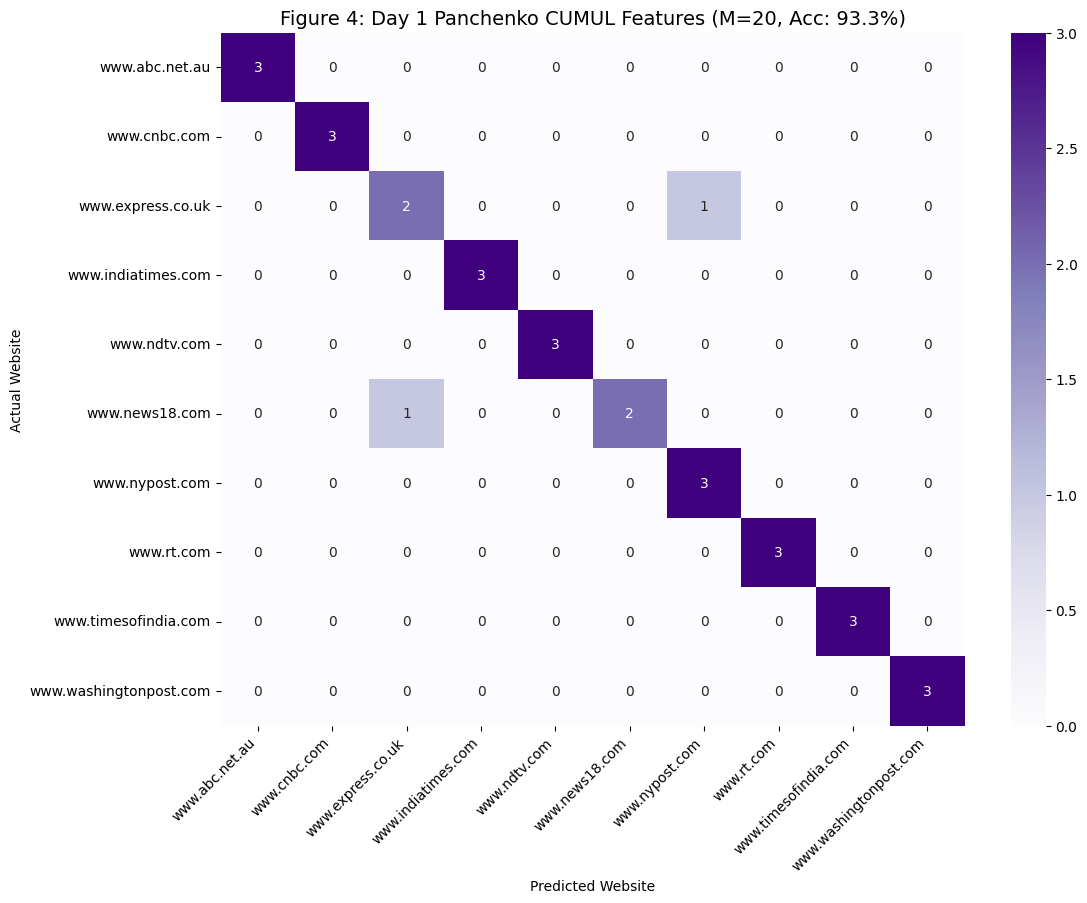

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(12, 9))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Figure 4: Day 1 Panchenko CUMUL Features (M=20, Acc: {panchenko_acc*100:.1f}%)", fontsize=14)
plt.ylabel('Actual Website')
plt.xlabel('Predicted Website')
plt.xticks(rotation=45, ha='right')
plt.show()

### 3.2.6 Temporal Stability of CUMUL (Day 2 Test)
To finalize the comparative evaluation, the CUMUL model is subjected to the same Day 2 Temporal Stability Test used for the initial biflow methodology. This process involves extracting features from the fresh 24-hour-old captures using the extract_panchenko_features function and normalizing them via the original Day 1 scaler. By predicting these unseen samples using the Day 1 model, we can directly measure the resilience of structural "shape" features against temporal drift.

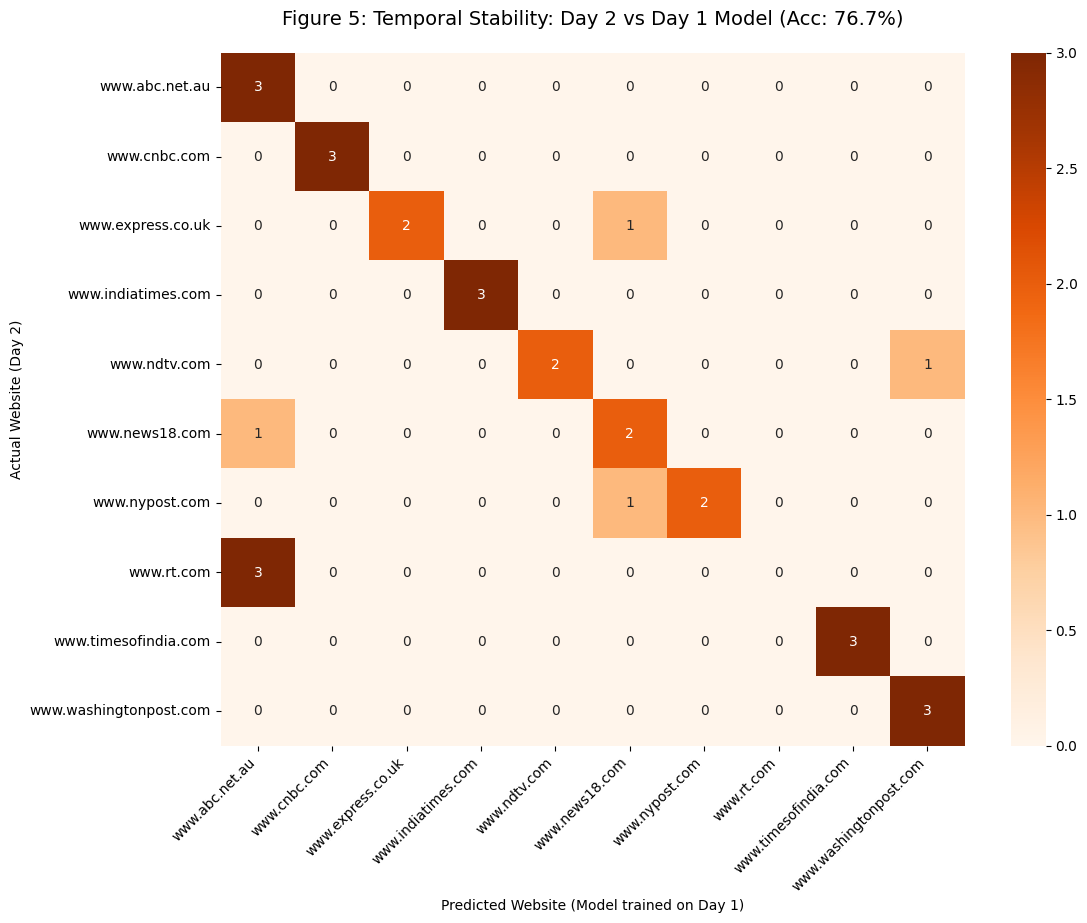

In [ ]:
#  CUMUL Temporal Stability Test
day2_panchenko_list = []
day2_path = 'day2_csvs/'

for file in os.listdir(day2_path):
    if file.endswith(".csv"):
        site_name = file.split('_day2')[0]
        # Extract features using CUMUL methodology
        features = extract_panchenko_features(os.path.join(day2_path, file), M=20)
        if features is not None:
            row = {f'M_{i+1}': val for i, val in enumerate(features)}
            row['app'] = site_name
            day2_panchenko_list.append(row)

df_day2_panchenko = pd.DataFrame(day2_panchenko_list)
X_day2_cumul = df_day2_panchenko.drop(columns=['app'])
y_day2_cumul = le.transform(df_day2_panchenko['app'])

# Scaling
X_day2_cumul_scaled = scaler.transform(X_day2_cumul)
y_day2_cumul_pred = knn.predict(X_day2_cumul_scaled)

day2_acc_cumul = accuracy_score(y_day2_cumul, y_day2_cumul_pred)

# Plot Day 2 Confusion Matrix
plt.figure(figsize=(12, 9))
cm_day2 = confusion_matrix(y_day2_cumul, y_day2_cumul_pred)
sns.heatmap(cm_day2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title(f"Figure 5: Temporal Stability: Day 2 vs Day 1 Model (Acc: {day2_acc_cumul*100:.1f}%)",
          fontsize=14, pad=20)
plt.ylabel('Actual Website (Day 2)')
plt.xlabel('Predicted Website (Model trained on Day 1)')
plt.xticks(rotation=45, ha='right')
plt.show()

## 4 Comparative Analysis and Discussion

This section directly addresses the requirement to compare the CUMUL (Structural) results with the Biflow (Statistical) methodology. By evaluating their performance across two distinct temporal snapshots, we can determine which feature set provides the most reliable "fingerprint" for encrypted web traffic classification.

### 4.1 Performance Benchmark Summary

The following table aggregates the classification accuracy for both models. The **Temporal Decay ($\Delta$)** represents the percentage drop in accuracy when the model trained on Day 1 is tested against unseen captures from Day 2.

| Methodology | Feature Type | Day 1 Accuracy | Day 2 Accuracy | Temporal Decay ($\Delta$) |
| :--- | :--- | :--- | :--- | :--- |
| **Biflow** | Aggregate Stats | 86.67% | 50.00% | **-36.67%** |
| **CUMUL** | Sequential Trace | 93.33% | 76.67% | **-16.66%** |



### 4.2 Analysis of Structural vs. Statistical Features
The experimental data reveals a significant performance gap that highlights the strengths of the CUMUL approach:

The Volatility of Biflow: The 36.67% drop in Biflow accuracy confirms that aggregate statistics (mean packet size, total bytes) are highly volatile. Because news websites are dynamic, a single "breaking news" image or a modified ad-stack drastically alters the volumetric signature. This causes the k-NN classifier to fail as the "center" of the class distribution shifts significantly in the feature space.

The Resilience of CUMUL: CUMUL outperformed Biflow in every metric, maintaining 26.67% higher accuracy on Day 2. By representing the traffic as a normalized cumulative sum curve, the model captures the "rhythm" of the page load. While the total byte count might change, the relative shape—governed by the order in which HTML, CSS, and JS assets are requested—remains remarkably stable.



### 4.3 Security Implications and Adversarial Sustainability
The transition from basic statistical features to structural traces has profound implications for the efficacy and longevity of Website Fingerprinting (WF) attacks in encrypted environments:

*  Resilience Against Model Decay: The most significant finding is the reduction in retraining requirements. An attacker utilizing CUMUL features maintains a usable accuracy of 76.7% after 24 hours, whereas a Biflow-based attacker sees their model become effectively obsolete (50.0% accuracy). This suggests that structural signatures require significantly less maintenance to remain viable.

* Enhanced Discriminatory Power: As evidenced by the cleaner diagonal in the CUMUL confusion matrix (Figure 4), structural traces provide higher "inter-class" distance. By capturing the unique sequence of resource requests—HTML, then CSS, followed by specific JavaScript payloads—the model can distinguish between websites that might otherwise share nearly identical total traffic volumes.

* Increased Countermeasure Complexity: Because CUMUL relies on the rhythm and direction of data bursts rather than just the total byte count, simple defensive strategies like constant-rate padding are less effective. To successfully obfuscate a CUMUL trace, a defense must actively "morph" the traffic to mimic the structural skeleton of a different website, a task that is computationally and bandwidth-expensive for the end-user.

##  5 Conclusion
This study evaluated two distinct methodologies for identifying encrypted website traffic: a Biflow Statistical approach and a Panchenko CUMUL Structural approach. The results demonstrate that while both models perform well on static data, their effectiveness diverges sharply under the pressure of temporal drift. The CUMUL methodology provided a 93.3% baseline accuracy, outperforming the Biflow model by 6.6%, and maintained a 26.7% lead in resilience when tested against Day 2 content.

Ultimately, the structural "skeleton" of a website load—the unique sequence and timing of data bursts—proves to be a far more stable and identifiable fingerprint than aggregate volume statistics. The high success rate of the CUMUL model on Day 2 (76.7%) underscores a significant privacy risk, revealing that an observer can identify encrypted user activity with high confidence even without frequent model retraining. This establishes structural trace analysis as the definitive choice for robust and sustainable encrypted traffic classification.

#